# Instruction Finetuning on Gemma-2b


### Installation

In [2]:
!pip install transformers==4.51.3  bitsandbytes==0.45.3 datasets peft accelerate trl safetensors

INFO: pip is looking at multiple versions of trl to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of trl to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.2/376.2 kB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 77.1 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: h

In [1]:
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

## **Inference on Gemma Base Model**

In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM,BitsAndBytesConfig

quantization_config = BitsAndBytesConfig(load_in_4bit=True)

token="" ## Use Your Token for Gated Models

tokenizer = AutoTokenizer.from_pretrained("google/gemma-2b", token=token)
model = AutoModelForCausalLM.from_pretrained("google/gemma-2b",token=token, quantization_config=quantization_config)

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/67.1M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

In [2]:
prompt = """State Section 1 of the Aadhaar (Targeted Delivery of Financial and other Subsidies, Benefits and Services) Act, 2016"""

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

outputs = model.generate(
    **inputs,
    max_new_tokens=512,
    do_sample=True,
    temperature=0.7,
    top_p=0.9,
    repetition_penalty=1.15,
)

print(tokenizer.decode(outputs[0]))

/usr/local/lib/python3.12/dist-packages/bitsandbytes/nn/modules.py:451: UserWarning: Input type into Linear4bit is torch.float16, but bnb_4bit_compute_dtype=torch.float32 (default). This will lead to slow inference or training speed.
  warnings.warn(


<bos>State Section 1 of the Aadhaar (Targeted Delivery of Financial and other Subsidies, Benefits and Services) Act, 2016

(This form is for identification of a person or class of persons to be eligible for an amount of subsidy under any scheme/programme/benefit/entitlement of targeted group. The Aadhaar Number should be mentioned wherever there is a column for such number).

\begin{enumerate}
  \item Particulars of Beneficiary
\end{enumerate}

a. Particulars of Beneficiaries with whom you are related

(Give name and relationship, if any, with all the beneficiaries covered by this entitlement):

b. Particulars of Beneficiaries who are dependent/otherwise needy:

(Give details of all those who will get the benefits; give their NIC numbers, in case of more than one) :

ii. Particulars of Beneficiaries whose names do not figure among the beneficiaries covered but would have been so entitled, had they been beneficentants at the time of announcement of the Scheme/Programme/Benefit/Entitleme

In [3]:
prompt = """
The Aadhaar (Targeted Delivery of Financial and other Subsidies, Benefits and Services) Act, 2016
Chapter I
Preliminary
1. Short title, extent and commencement.-
"""

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

outputs = model.generate(
    **inputs,
    max_new_tokens=512,
    do_sample=True,
    temperature=0.7,
    top_p=0.9,
    repetition_penalty=1.15,
)

print(tokenizer.decode(outputs[0]))

<bos>
The Aadhaar (Targeted Delivery of Financial and other Subsidies, Benefits and Services) Act, 2016
Chapter I
Preliminary
1. Short title, extent and commencement.-
(1)	Short title.-(1)	(a)	This Act may be called the Aadhaar (Targeted Delivery of Financial and other Subsidies, Benefits and Services)
(b)	The Act shall be named as the Aadhaar (Targeted Delivery of Financial and other Subsidies, Benefits and Services) Act, 2016 and shall be of\'wide\' � extent.-(1B)	(a)	In this Act, unless the contrary intention appears,—(a)	'Aadhaar Number'� means an eighteen-digit number, which is assigned by the Unique Identification Authority of India or any other authority specified by it, in accordance with the provisions of this Act; (b)	'Aadhaar card'� means the identity or ration card, whichever is so designated, to which the Aadhaar Number is linked; (c)	'beneficiary'�, in relation to any scheme, includes—(i)	every person who is--(A)	entitled under the scheme to receive a subsidy, compen-sati

In [4]:
prompt = """
A fever is a temporary increase in body temperature, usually
"""

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

outputs = model.generate(
    **inputs,
    max_new_tokens=512,
    do_sample=True,
    temperature=0.7,
    top_p=0.9,
    repetition_penalty=1.15,
)

print(tokenizer.decode(outputs[0]))

<bos>
A fever is a temporary increase in body temperature, usually
associated with an infection.
Bacterial and viral infections can cause fevers.

<h2>Bacterial Infections</h2>

Bacterial infections such as bronchitis and pneumonia are the most common causes of fevers.

Viral Infections

Viral infections like the common cold and influenza viruses also cause fevers.

Fungal Infections

Fungi (molds and yeast) may play a role in the pathogenesis of several autoimmune diseases.

<h2>Cancer</h2>

Cancers that produce cytokines, such as Hodgkin's disease and non-Hodgkin's lymphomas, have been shown to trigger or exacerbate inflammatory responses by recruiting inflammatory cells, such as T-cells and macrophages, and possibly B-lymphocytes.

Tumor Necrosis Factor-α (TNF-α)

Tumor necrosis factor (TNF-α) is a cytokine that has pleiotropic and/or multifactorial roles in tumorigenesis, inflammation, and immunopathology.

Interleukins

Interleukin 12 (IL-12) is a heterodimeric cytokine that is co

In [5]:
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

## **Instruction Finetuning**

In [2]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

use_flash_attention = True

model_id = "google/gemma-2b"


# token ="Your HF Token"


# BitsAndBytesConfig int-4 config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True
)

# Load model and tokenizer
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    use_cache=False,
    device_map="auto",
    # token=token,
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

## **PEFT Configration**

In [3]:
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model

# LoRA config based on QLoRA paper
peft_config = LoraConfig(
        lora_alpha=64,
        lora_dropout=0,
        r=128,
        bias="none",
        task_type="CAUSAL_LM",
)


# prepare model for training
model = prepare_model_for_kbit_training(model)
model = get_peft_model(model, peft_config)

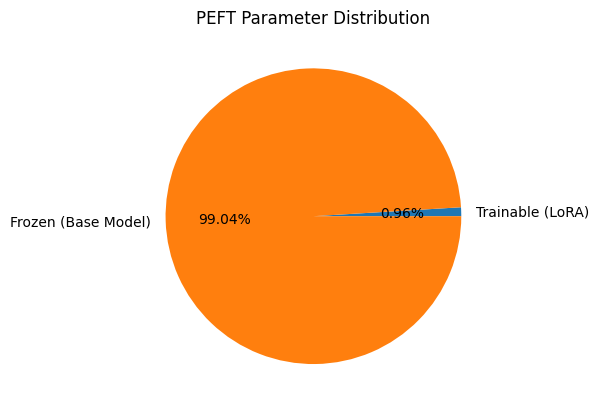

In [4]:
import matplotlib.pyplot as plt

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)

plt.figure()
plt.pie(
    [trainable, frozen],
    labels=["Trainable (LoRA)", "Frozen (Base Model)"],
    autopct="%1.2f%%"
)
plt.title("PEFT Parameter Distribution")
plt.show()

<a name="Data"></a>
### Data Prep

In [13]:
from datasets import load_dataset
from random import randrange

dataset = load_dataset("mratanusarkar/Indian-Laws", split="train")

total = len(dataset)
one_percent = int(total * 0.0002)

dataset = dataset.select(range(0, one_percent)) ## Only using 1% of total dataset for faster training

print("Dataset Lenghth:", len(dataset))

Dataset Lenghth: 6


In [14]:
print(dataset[0])

{'act_title': 'Aadhaar (Targeted Delivery of Financial and other Subsidies, Benefits and Services) Act, 2016', 'section': '1', 'law': 'The Aadhaar (Targeted Delivery of Financial and other Subsidies, Benefits and Services) Act, 2016\nChapter I\nPreliminary\n1. Short title, extent and commencement.-\n(1) This Act may be called the Aadhaar (Targeted Delivery of Financial and Other Subsidies, Benefits and Services) Act, 2016.\n(2) It shall extend to the whole of India 2*** and save as otherwise provided in this Act, it shall also apply to any offence or contravention thereunder committed outside India by any person.\n(3) It shall come into force on such date3 as the Central Government may, by notification in the Official Gazette, appoint; and different dates may, be appointed for different provisions of this Act and any reference in any such provision to the commencement of this Act shall be construed as a reference to the commencement of that provision.'}


In [15]:
def format_instruction(sample):
	return f"""### Instruction:
You are an Indian Law Expert. Write a response that appropriately completes the request.

### Input:
State Section {sample["section"]} of {sample["act_title"]}

### Response:
{sample['law']}
"""

In [16]:
from random import randrange

print(format_instruction(dataset[randrange(len(dataset))]))

### Instruction:
You are an Indian Law Expert. Write a response that appropriately completes the request.
 
### Input:
State Section 14 of Aadhaar (Targeted Delivery of Financial and other Subsidies, Benefits and Services) Act, 2016
 
### Response:
The Aadhaar (Targeted Delivery of Financial and other Subsidies, Benefits and Services) Act, 2016
14. Term of office and other conditions of service of Chairperson and Members.-
(1) The Chairperson and the Members appointed under this Act shall hold office for a term of three years from the date on which they assume office and shall be eligible for re-appointment:
Provided that no person shall hold office as the Chairperson or Member after he has attained the age of sixty-five years.
(2) The Chairperson and every Member shall, before entering office, make and subscribe to, an oath of office and of secrecy, in such form and in such manner and before such Authority as may be prescribed.
(3) Notwithstanding anything contained in sub-section (1)

We only use 5% of the dataset to speed things up! Use more for longer runs!

## **SFT Configration**

In [17]:
from trl import SFTConfig
max_seq_length = 2048


args = SFTConfig(
    output_dir="gemma-ft-law",
    num_train_epochs=5,
    per_device_train_batch_size=1,
    max_length=max_seq_length,
    gradient_accumulation_steps=2,
    gradient_checkpointing=True,
    optim="paged_adamw_32bit",
    logging_steps=25,
    packing=True,
    save_strategy="epoch",
    learning_rate=2e-4,
    bf16=True,
    tf32=False,
    max_grad_norm=0.3,
    warmup_ratio=0.03,
    lr_scheduler_type="constant",
    disable_tqdm=False
)

average_tokens_across_devices is set to True but it is invalid when world size is1. Turn it to False automatically.


## **Model Finetuting**

In [18]:
from trl import SFTTrainer

trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    peft_config=peft_config,
    processing_class=tokenizer,
    formatting_func=format_instruction,
    args=args,
)

/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:412: UserWarning: Padding-free training is enabled, but the attention implementation is not set to 'flash_attention_2'. Padding-free training flattens batches into a single sequence, and 'flash_attention_2' is the only known attention mechanism that reliably supports this. Using other implementations may lead to unexpected behavior. To ensure compatibility, set `attn_implementation='flash_attention_2'` in the model configuration, or verify that your attention mechanism can handle flattened sequences.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:458: UserWarning: You are using packing, but the attention implementation is not set to 'flash_attention_2'. Packing flattens batches into a single sequence, and 'flash_attention_2' is the only known attention mechanism that reliably supports this. Using other implementations may lead to cross-contamination between batches. To avoid this, ei

Applying formatting function to train dataset:   0%|          | 0/6 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/6 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/6 [00:00<?, ? examples/s]

Packing train dataset:   0%|          | 0/6 [00:00<?, ? examples/s]

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [19]:
# train
trainer.train()

Step,Training Loss


wandb: WARNING The get_url method is deprecated and will be removed in a future release. Please use `run.url` instead.
wandb: WARNING URL not available in offline run
/usr/local/lib/python3.12/dist-packages/peft/utils/other.py:1394: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-69ce2a43-69681e89730b30630e974595;a2694c39-d0dc-4b08-84c4-73cb9709edf4)

Cannot access gated repo for url https://huggingface.co/google/gemma-2b/resolve/main/config.json.
Access to model google/gemma-2b is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in google/gemma-2b.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:295: UserWarning: Could not find a config file in google/gemma-2b - will assume that the vocabulary was not modified.
  warnings.warn(
wandb: WARNING URL not available in offline run
/usr/local/lib/python3

TrainOutput(global_step=5, training_loss=0.851038646697998, metrics={'train_runtime': 62.8572, 'train_samples_per_second': 0.08, 'train_steps_per_second': 0.08, 'total_flos': 75532513505280.0, 'train_loss': 0.851038646697998})

In [20]:
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

## **Merging and Saving finetuned model**

In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import torch

# ---- Config ----
base_model_id = "google/gemma-2b" # base model
adapter_path = "gemma-ft-law/checkpoint-3/"  # your fine-tuned adapter path (corrected to checkpoint-3)
output_path = "Merged-IF-Gemma-2b-Indina-Law"  # Merged output

# ---- Load base model in full precision (no quant) ----
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

# ---- Load LoRA adapter and merge ----
model = PeftModel.from_pretrained(base_model, adapter_path)
model = model.merge_and_unload()

# ---- Save merged model ----
model.save_pretrained(output_path)
tokenizer = AutoTokenizer.from_pretrained(base_model_id)
tokenizer.save_pretrained(output_path)

print(f"Merged model saved at {output_path}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Merged model saved at Merged-IF-Gemma-2b-Indina-Law


In [2]:
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

## **Perplexity Score Measurement**

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

quantization_config = BitsAndBytesConfig(load_in_4bit=True)

model_name = "google/gemma-2b"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    quantization_config=quantization_config
)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [3]:
alpaca_prompt = """You are an Indian Law Expert. Write a response that appropriately completes the request.

### Instruction:
State Section {} of {}

### Response:
{}"""


EOS_TOKEN = tokenizer.eos_token

def formatting_prompts_func(batch):
    texts = []
    for act_title, section, law in zip(batch["act_title"], batch["section"], batch["law"]):
        text = alpaca_prompt.format(section, act_title, law) + EOS_TOKEN
        texts.append(text)
    return {"text": texts}

In [4]:
from datasets import load_dataset

dataset = load_dataset("mratanusarkar/Indian-Laws", split="train")

total = len(dataset)
subset_size = int(total * 0.005)
dataset = dataset.select(range(subset_size))

print("Eval Dataset Length: ", len(dataset))

formatted_dataset = dataset.map(formatting_prompts_func, batched=True)
texts = formatted_dataset["text"]

Eval Dataset Length:  171


Map:   0%|          | 0/171 [00:00<?, ? examples/s]

In [5]:
import math

def compute_perplexity(texts, model, tokenizer, max_length=512):
    losses = []

    for text in texts:
        enc = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=max_length
        ).to(model.device)

        with torch.no_grad():
            outputs = model(
                **enc,
                labels=enc["input_ids"]
            )
            losses.append(outputs.loss.item())

    mean_loss = sum(losses) / len(losses)
    return math.exp(mean_loss)

In [6]:
ppl = compute_perplexity(texts, model, tokenizer)
print("Base Gemma Perplexity Score:", ppl)

Base Gemma Perplexity Score: 9.828582651314596


In [7]:
model_name = "Merged-IF-Gemma-2b-Indina-Law"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    quantization_config=quantization_config
)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [8]:
ppl = compute_perplexity(texts, model, tokenizer)
print("Instruction Finetuned Gemma Perplexity Score:", ppl)

Instruction Finetuned Gemma Perplexity Score: 6.758239019458158


In [9]:
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

## **Inference on Gemma-2b Instruction Finetuned Model**

In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

quantization_config = BitsAndBytesConfig(load_in_4bit=True)

token="" ## Use Your Token for Gated Models

tokenizer = AutoTokenizer.from_pretrained("Merged-IF-Gemma-2b-Indina-Law")
model = AutoModelForCausalLM.from_pretrained("Merged-IF-Gemma-2b-Indina-Law", quantization_config=quantization_config)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [2]:
prompt = """You are an Indian Law Expert. Write a response that appropriately completes the request.

### Instruction:
State Section 1 of the Aadhaar (Targeted Delivery of Financial and other Subsidies, Benefits and Services) Act, 2016

### Rersponse:
"""

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

outputs = model.generate(
    **inputs,
    max_new_tokens=512,
    do_sample=True,
    temperature=0.7,
    top_p=0.9,
    repetition_penalty=1.15,
)

print(tokenizer.decode(outputs[0]))

/usr/local/lib/python3.12/dist-packages/bitsandbytes/nn/modules.py:451: UserWarning: Input type into Linear4bit is torch.float16, but bnb_4bit_compute_dtype=torch.float32 (default). This will lead to slow inference or training speed.
  warnings.warn(


<bos>You are an Indian Law Expert. Write a response that appropriately completes the request.

### Instruction:
State Section 1 of the Aadhaar (Targeted Delivery of Financial and other Subsidies, Benefits and Services) Act, 2016

### Rersponse:
Section 3 of the Aadhaar (Targeted Delivery of Financial and other Subsidies, Benefits and Services) Act, 416 provides that where there is any inconsistency between this Act and any previous legislation relating to Aadhaar, the provisions of this Act shall prevail.<eos>


In [3]:
prompt = """You are an Indian Law Expert. Write a response that appropriately completes the request.

### Instruction:
State Section 11 of the Aadhaar (Targeted Delivery of Financial and other Subsidies, Benefits and Services) Act, 2016

### Rersponse:
"""

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

outputs = model.generate(
    **inputs,
    max_new_tokens=512,
    do_sample=True,
    temperature=0.7,
    top_p=0.9,
    repetition_penalty=1.15,
)

print(tokenizer.decode(outputs[0]))

<bos>You are an Indian Law Expert. Write a response that appropriately completes the request.

### Instruction:
State Section 11 of the Aadhaar (Targeted Delivery of Financial and other Subsidies, Benefits and Services) Act, 2016

### Rersponse:
Section 45-A(2)(i) defines "Aadhaar number" as the unique identification number allotted to every citizen in accordance with this Act.

Hence, option 4 is correct.<eos>
